In [2]:
import numpy as np
import matplotlib.pyplot as plt

def npz_nl(x, t, Vm, ks, m, Rm, ivlev, gamma, q):
    x = np.asarray(x)
    dx = np.zeros(x.shape)

    
    dx[1] = (((Vm * x[0]) / (ks + x[0])) * x[1]) - (m * x[1]) - (ivlev * x[1] * Rm * (1 - np.exp(-ivlev * x[1])) * x[2])
    dx[2] = ((1 - gamma) * ivlev * x[1] * Rm * (1 - np.exp(-ivlev * x[1])) * x[2]) - (q * x[2])
    dx[0] = -(((Vm * x[0]) / (ks + x[0])) * x[1]) + (m * x[1]) + (q * x[2]) + (gamma * ivlev * x[1] * Rm * (1 - np.exp(-ivlev * x[1])) * x[2])
    
    return dx

def simple_npz_nl(x, t, alpha, beta, b, c, e, f):
    x = np.asarray(x)
    dx = np.zeros(x.shape)

    
    dx[1] = (((alpha * np.tanh(beta * x[0])) * x[1]) - (b * (x[1]**2)) - ((e + f) * (x[1] * x[2])))
    dx[2] = ((e * (x[1] * x[2])) - (c * (x[2]**2)))
    dx[0] = (-((alpha * np.tanh(beta * x[0])) * x[1]) + (b * (x[1]**2)) + (c * (x[2]**2)) + (f * (x[1] * x[2])))
    
    return dx
    
def rk4(f, x0, times, tfrc, frc, args):
    """
    Perform the model integration using the Runge-Kutta 4. This
    allows for the function to be forced at given times, ft, by the forcing, f.
    """
    nt = len(times)
    x = np.zeros((nt, len(x0)))
    x[0, :] = x0
    dt = np.zeros(nt)
    dt[1:] = np.diff(times)
    for n in range(1, nt):
        k1 = f(x[n - 1, :], times[n], *args) * dt[n]
        k2 = f(x[n - 1, :] + 0.5 * k1, times[n] + 0.5 * dt[n], *args) * dt[n]
        k3 = f(x[n - 1, :] + 0.5 * k2, times[n] + 0.5 * dt[n], *args) * dt[n]
        k4 = f(x[n - 1, :] + k3, times[n] + dt[n], *args) * dt[n]
        x[n, :] = x[n - 1, :] + (k1 + 2 * k2 + 2 * k3 + k4) / 6

        if tfrc is not None:
            fl = np.where(np.logical_and(tfrc >= times[n] - 0.5 * dt[n],
                                         tfrc < times[n] + 0.5 * dt[n]))[0]
            x[n, :] += f[fl, :].sum(axis=0)

    return x

# RK4 for a single set of initial conditions
def run_rk4_for_initial_conditions(N0, P0, Z0, t, phi):
    # Define the initial conditions as a list
    x0 = [N0, P0, Z0]
    # Use the rk4 method to expand the system over time
    xt = rk4(npz_nl, x0, t, None, 0, phi)
    return xt

def pinn_npz(x, t, alpha, beta, b, c, e, f):
    x = np.asarray(x)
    dx = np.zeros(x.shape)

    dx[1] = (((alpha * np.tanh(beta * x[0])) * x[1]) - (b * (x[1])) - ((e + f) * (x[1] * x[2])))
    dx[2] = ((e * (x[1] * x[2])) - (c * (x[2])))
    dx[0] = (-((alpha * np.tanh(beta * x[0])) * x[1]) + (b * (x[1])) + (c * (x[2])) + (f * (x[1] * x[2])))
    
    return dx
    
# RK4 for a single set of initial conditions
def run_rk4_pinn_npz(N0, P0, Z0, t, phi):
    # Define the initial conditions as a list
    x0 = [N0, P0, Z0]
    # Use the rk4 method to expand the system over time
    xt = rk4(pinn_npz, x0, t, None, 0, phi)
    return xt

# RMSE function
def calculate_rmse(actual, predicted):
    residuals = actual - predicted
    rmse = np.sqrt(np.mean(residuals ** 2))
    return rmse

# Define a function to calculate relative error
def calculate_rel_error(actual, predicted):
    with np.errstate(divide='ignore', invalid='ignore'):  # Ignore division by zero warnings
        relative_error = np.abs(predicted - actual) / actual  # Relative Error
        relative_error = np.where(np.isnan(relative_error) | np.isinf(relative_error), 0, relative_error)  # Handle division by zero or NaN cases
    
    rel_error = np.mean(relative_error)
    return rel_error
    

In [3]:
# Define the parameters for the system
Vm = 2
ks = 1
m = 0.1
gamma = 0.3
Rm = 1.5
ivlev = 1
q = 0.2
phi = (Vm, ks, m, Rm, ivlev, gamma, q)

# Define the time parameters
tstart = 0  # Start time (day 0)
tend = 7 # End time (day 7)
minutes_per_step = 10  # Time step in minutes
minutes_per_hour = 60  # Constant time per hour
hours_per_day = 24  # Constant time per day
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
t = np.arange(tstart, tend + dt, dt)  # Create the array of times

N0 = 1.6
P0 = 0.3
Z0 = 0.1

# Run RK4 with these initial conditions
original_npz = run_rk4_for_initial_conditions(N0, P0, Z0, t, phi)


In [8]:
alpha = 1.2187
beta = 1.2667
b = 0.1
c = 0.2
e = 0.56
f = 0.44

phi_pinn = (alpha, beta, b, c, e, f)
# Run RK4 with these initial conditions
pinn_npz_result = run_rk4_pinn_npz(N0, P0, Z0, t, phi_pinn)


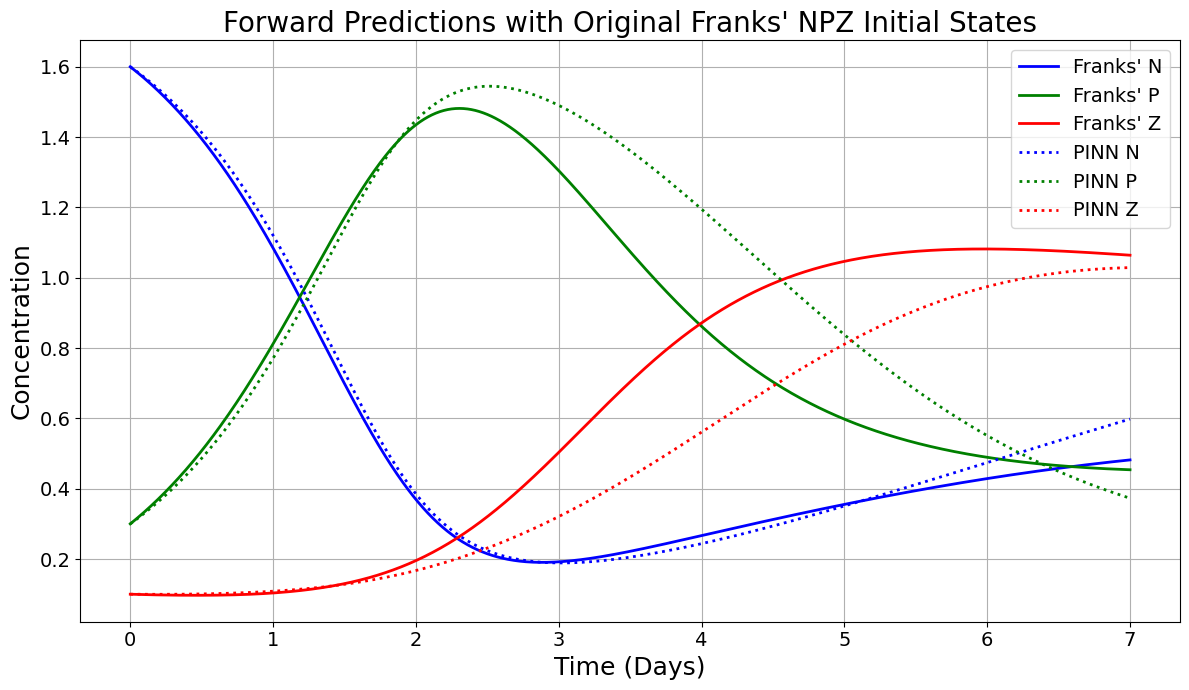

RMSE between Original Franks' and NN: 0.1410347608743096


In [9]:
total_days = 7 # / 24

intervals_per_day = 24 * 2 * 3 # 15 minute intervals (2 per hour)

# Calculate the total number of half-hour intervals
total_intervals = total_days * intervals_per_day

# Create an array from 0 to 7 days with half-hour intervals
times = np.arange(0, total_days + 1/intervals_per_day, 1/intervals_per_day)

if times[-1] > total_days:
    times = times[:-1]
# Plotting the results for the GELU model
output_names = ["N", "P", "Z"]
plt.figure(figsize=(12, 7))  # Slightly larger for presentations

# Plot actual values
len_plot = len(original_npz)
plt.plot(times, original_npz[:-1, 0], label="Franks' N", color='b', linewidth=2)
plt.plot(times, original_npz[:-1, 1], label="Franks' P", color='g', linewidth=2)
plt.plot(times, original_npz[:-1, 2], label="Franks' Z", color='r', linewidth=2)

plt.plot(times, pinn_npz_result[:-1, 0], label="PINN N", color='b', linestyle='dotted', linewidth=2)
plt.plot(times, pinn_npz_result[:-1, 1], label="PINN P", color='g', linestyle='dotted', linewidth=2)
plt.plot(times, pinn_npz_result[:-1, 2], label="PINN Z", color='r', linestyle='dotted', linewidth=2)

# Labels and title with increased font sizes
plt.xlabel('Time (Days)', fontsize=18)
plt.ylabel('Concentration', fontsize=18)
plt.title("Forward Predictions with Original Franks' NPZ Initial States", fontsize=20)

# Ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Legend
plt.legend(fontsize=14)

# Grid and layout
plt.grid(True)
plt.tight_layout()

# Save high-res for presentation
# plt.savefig(
#     "/Users/egank31/Documents/Documents - Otto/lab_meetings/figures/original_npz_states_predictions.png",
#     dpi=300,
#     bbox_inches='tight',
#     pad_inches=0.1
# )

plt.show()

rmse_original_franks = calculate_rmse(pinn_npz_result, original_npz)
print(f"RMSE between Original Franks' and NN: {rmse_original_franks}")

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
import pandas as pd
import random
from scipy.optimize import brentq

# Helper functions
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

In [11]:
min_N=0.001
min_P=0.001
min_Z=0.001

In [12]:
def npz(tstart=0, tend=50, dt=0.001, N0=1.6, P0=0.3, Z0=0.1, Vm=2.0,
        ks=1.0, m=0.1, gamma=0.3, Rm=1.5, ivlev=1.0, q=0.2, mp=True):

    # Create the variables to store our results
    times = np.arange(tstart, tend + dt, dt)  # Create the array of times
    Nt = len(times)                           # Number of time-steps
    N = np.zeros(Nt)                          # Create time array of N
    P = np.zeros(Nt)                          # Create time array of P
    Z = np.zeros(Nt)                          # Create time array of Z

    # Set our initial conditions
    N[0] = N0
    P[0] = P0
    Z[0] = Z0
    print(N0, P0, Z0)

    # Determine the Fixed Points
    Ntot = N0 + P0 + Z0
    print(Ntot)
    Pf = ((-1.0 / (ivlev * Ntot)) * np.log(1 - ((q / Vm) / ((Rm / Vm) * (1 - gamma)))))
    if mp:
        # def fpf(ppf): return (ppf * (1. - np.exp(-ivlev * Ntot * ppf))) - \
        #     ((q / Vm) / ((Rm / Vm) * ivlev * Ntot * (1. - gamma)))

        def fpf(ppf):
            omega = q * Vm**-1
            beta = Rm * Vm**-1
            ivlev_lambda = ivlev * Ntot
            lhs = (ppf * (1. - np.exp(-ivlev_lambda * ppf)))
            rhs = (omega / ((beta * ivlev_lambda) * (1. - gamma)))
            # print(f"Evaluating fpf at ppf={ppf:.5f}: lhs={lhs:.5f}, rhs={rhs:.5f}, result={lhs - rhs:.5f}")
            result = lhs - rhs
            
            return result
            
        # Pf = np.min(fsolve(fpf, np.array([0.01, 0.99])))
        Pf = brentq(fpf, 0.01, 0.99)
    a = -(q / Vm) / (1 - gamma)
    b = ((q / Vm) / (1 - gamma)) * ((ks / Ntot) + 1 - Pf) + Pf - ((m / Vm) * Pf)
    c = Pf * ((m / Vm) * ((ks / Ntot) + 1 - Pf) + Pf - 1)
    Zf = np.minimum((-b + np.sqrt(b * b - 4 * a * c)) / (2 * a),
                    (-b - np.sqrt(b * b - 4 * a * c)) / (2 * a))
    Nf = 1 - Pf - Zf
    Pf = Pf * Ntot
    Zf = Zf * Ntot
    Nf = Nf * Ntot

    print(f"Fixed Points: N={Nf}, P={Pf}, Z={Zf}")
    
    # Loop over all of our times and integrate the model
    for n in range(Nt - 1):
        # Solve the semi-implicit
        # Uptake
        uptake = Vm * P[n] / (ks + N[n])
        N[n + 1] = N[n] / (1 + uptake * dt)
        P[n + 1] = P[n] + dt * uptake * N[n + 1]

        # Grazing
        if mp:                              # Use Mayzaud-Poulet
            grazing = Rm * ivlev * (1 - np.exp(-ivlev * P[n + 1])) * Z[n]
            P[n + 1] = P[n + 1] / (1 + grazing * dt)
            N[n + 1] = N[n + 1] + P[n + 1] * gamma * grazing * dt
            Z[n + 1] = Z[n] + P[n + 1] * (1 - gamma) * grazing * dt
        else:                               # Use Ivlev
            grazing = Rm * (1 - np.exp(-ivlev * P[n + 1])) * Z[n]
            ratio = 1 / (1 + (grazing * dt / P[n + 1]))
            N[n + 1] = N[n + 1] + gamma * grazing * dt * ratio
            Z[n + 1] = Z[n] + (1 - gamma) * grazing * dt * ratio
            P[n + 1] = P[n + 1] * ratio

        # Mortality
        P[n + 1] = P[n + 1] / (1 + m * dt)
        Z[n + 1] = Z[n + 1] / (1 + q * dt)
        N[n + 1] = N[n + 1] + dt * (q * Z[n + 1] + m * P[n + 1])

        # Apply the boundary conditions
        N[n + 1] = np.maximum(N[n + 1], min_N)
        P[n + 1] = np.maximum(P[n + 1], min_P)
        Z[n + 1] = np.maximum(Z[n + 1], min_Z)

    return times, N, P, Z, Nf, Pf, Zf


1.6 0.3 0.1
2.0
Fixed Points: N=0.5140419186368684, P=0.4909638339256613, Z=0.9949942474374703


Text(0, 0.5, 'P [$\\mu$ g N L$^{-1}$]')

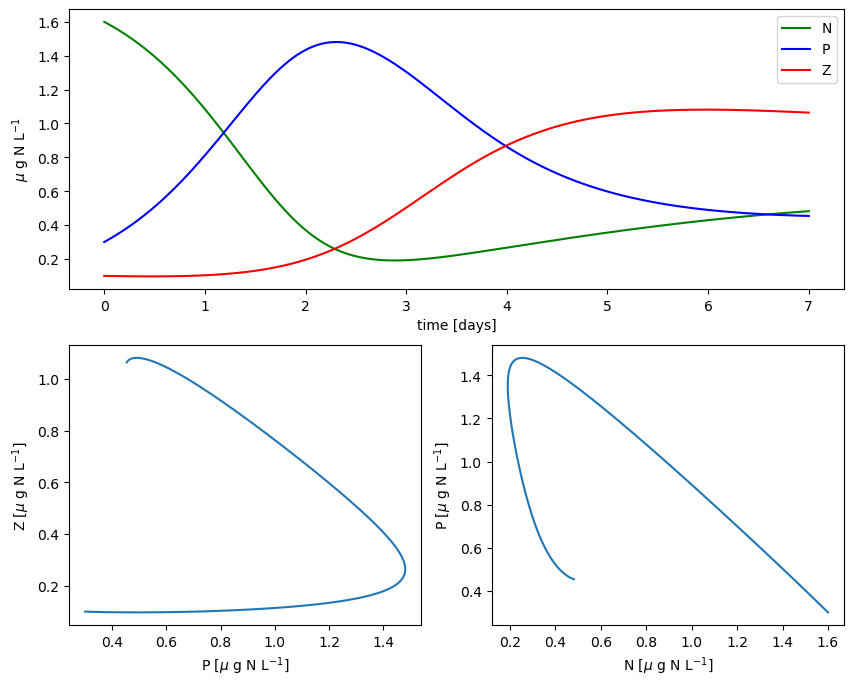

In [13]:
N0 = 1.6
P0 = 0.3
Z0 = 0.1
# N0, P0, Z0 = 11, 2.0625, 0.6875
# N0 = n0
# P0 *= N0 / N0_original
# Z0 *= N0 / N0_original
Vm=2.0
ks=1.0
m=0.1
gamma=0.3
Rm=1.5
ivlev=1.0
q=0.2

tstart = 0 # Start time (day 0)
tend = 7 # End time (day 8)
minutes_per_step = 1 # Time step in minutes
minutes_per_hour = 60 # Constant time per hour
hours_per_day = 24 # Constant time per day
dt = minutes_per_step / (minutes_per_hour * hours_per_day)
times_orig, N_orig, P_orig, Z_orig, Nf_orig, Pf_orig, Zf_orig = npz(tend=tend, dt=dt,
                                                                    N0=N0, P0=P0, Z0=Z0,
                                                                    Vm=Vm, ks=ks, m=m,
                                                                    gamma=gamma, Rm=Rm,
                                                                    ivlev=ivlev, q=q)
fig = plt.figure(figsize=(10,8))
ax = [0, 0, 0]
ax[0] = plt.subplot2grid((2,2), (0,0), colspan=2)
ax[1] = plt.subplot2grid((2,2), (1,0))
ax[2] = plt.subplot2grid((2,2), (1,1))

ax[0].plot(times_orig,N_orig,'g',times_orig,P_orig,'b',times_orig,Z_orig,'r')
ax[0].set_xlabel("time [days]")
ax[0].set_ylabel("$\\mu$ g N L$^{-1}$")
ax[0].legend(["N","P","Z"])

ax[1].plot(P_orig,Z_orig)
ax[1].set_xlabel("P [$\\mu$ g N L$^{-1}$]")
ax[1].set_ylabel("Z [$\\mu$ g N L$^{-1}$]")

ax[2].plot(N_orig,P_orig)
ax[2].set_xlabel("N [$\\mu$ g N L$^{-1}$]")
ax[2].set_ylabel("P [$\\mu$ g N L$^{-1}$]")

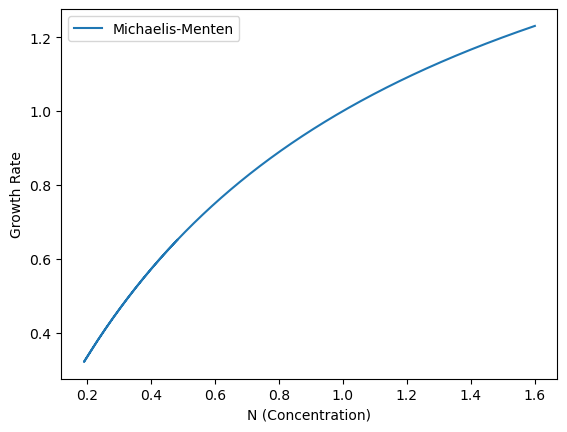

In [14]:
# Parameters for the Michaelis-Menten equation
Vm = 2.0  # Maximum growth rate
ks = 1.0  # Half-Saturation constant for nitrate

# Define the Michaelis-Menten function
def michaelis_menten(N, Vm, ks):
    return Vm * N / (ks + N)

MM_values = michaelis_menten(N_orig, Vm, ks)

# Plot the Michaelis-Menten function
plt.plot(N_orig, MM_values, label='Michaelis-Menten')
plt.xlabel('N (Concentration)')
plt.ylabel('Growth Rate')
plt.legend()
plt.show()


Pseudo Max Growth Rate (a): 1.2164
Pseudo Half-Saturation constant for nitrate (b): 1.2795


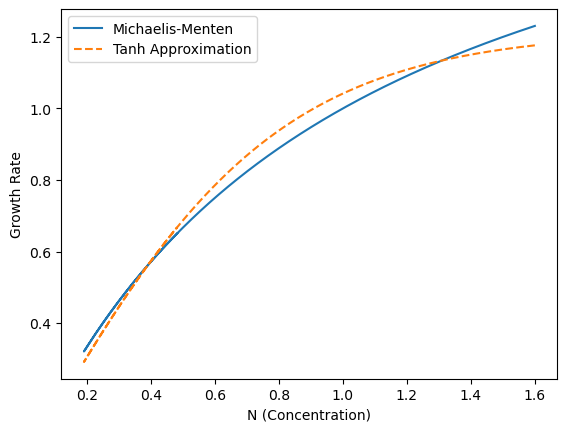

RMSE between tanh approximation and MM term: 0.023800


In [15]:
np.random.seed(1234)

# Using hyperbolic tangent to approximate Michaelis-Menten (MM) dynamics
def tanh_approx(N, a, b):
    return a * np.tanh(b * N)

# Initial guess for the parameters
initial_guess = [Vm, ks]

# Fit the tanh function to the Michaelis-Menten data
mm_params, _ = curve_fit(tanh_approx, N_orig, MM_values, p0=initial_guess)

# Extract optimized parameters
a, b = mm_params
print(f"Pseudo Max Growth Rate (a): {a:.4f}")
print(f"Pseudo Half-Saturation constant for nitrate (b): {b:.4f}")
# Calculate the tanh approximation values
tanh_values = tanh_approx(N_orig, a, b)

# Plot Michaelis-Menten function vs. tanh approximation
plt.plot(N_orig, MM_values, label='Michaelis-Menten')
plt.plot(N_orig, tanh_values, label='Tanh Approximation', linestyle='--')
plt.xlabel('N (Concentration)')
plt.ylabel('Growth Rate')
plt.legend()
plt.show()

# Compute RMSE
rmse_tanh = np.sqrt(np.mean((MM_values - tanh_values) ** 2))
print(f"RMSE between tanh approximation and MM term: {rmse_tanh:.6f}")


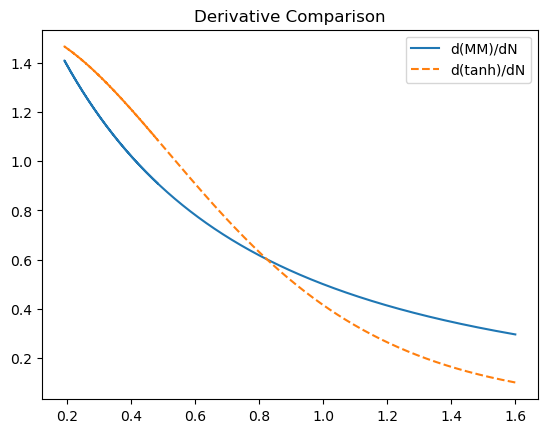

In [16]:
d_MM = np.gradient(MM_values, N_orig)
d_tanh = np.gradient(tanh_values, N_orig)

plt.plot(N_orig, d_MM, label='d(MM)/dN')
plt.plot(N_orig, d_tanh, '--', label='d(tanh)/dN')
plt.legend()
plt.title('Derivative Comparison')
plt.show()
